In [227]:
### Homework 4 Code - Karann Singam - 801285554 ###

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn import metrics

In [228]:
# Mounting Google Drive and reading CSV file
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ECGR_4105/Datasets/Cancer.csv')

# Initializing variables
Y = df.iloc[:, 1]
Y = Y.map({"B": 0, "M": 1})
X = df.iloc[:, 2:32]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Baseline Accuracy = 0.9035087719298246 
Baseline Precision = 0.7142857142857143 
Baseline Recall = 0.9615384615384616

Tuned Accuracy = 0.9122807017543859 
Tuned Precision = 0.7352941176470589 
Tuned Recall = 0.9615384615384616 



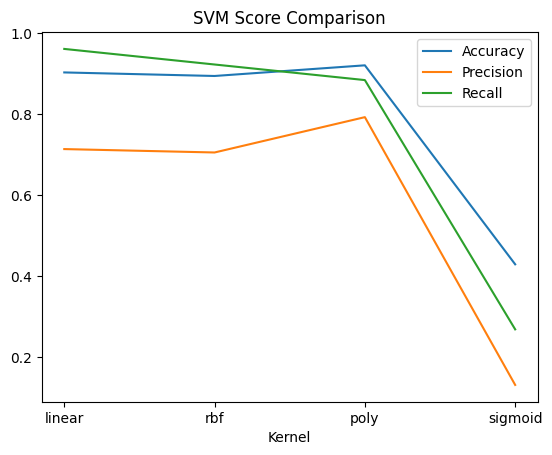

In [229]:
### Problem 1 ###

# Splitting 80/20 for training/test
split = int(0.8 * len(X))
indices = list(range(len(X)))
XT = X.iloc[indices[:split]].values
XV = X.iloc[indices[split:]].values
YT = Y.iloc[indices[:split]].values
YV = Y.iloc[indices[split:]].values

# Standardization
XT = (XT - XT.mean()) / XT.std()
XV = (XV - XV.mean()) / XV.std()

# Baseline SVM classification (kernel is linear, C is 1.0, gamma is "scale") and finding metrics
classifier = SVC(kernel = "linear")
classifier.fit(XT, YT)
predictions = classifier.predict(XV)
accuracy = metrics.accuracy_score(YV, predictions)
precision = metrics.precision_score(YV, predictions)
recall = metrics.recall_score(YV, predictions)
print("Baseline Accuracy =", accuracy, "\nBaseline Precision =", precision, "\nBaseline Recall =", recall)

# Tuned SVM classification kernel, C, and gamma and finding metrics
classifier = SVC(kernel = "poly", C = 0.5, gamma = 0.2)
classifier.fit(XT, YT)
predictions = classifier.predict(XV)
accuracy = metrics.accuracy_score(YV, predictions)
precision = metrics.precision_score(YV, predictions)
recall = metrics.recall_score(YV, predictions)
print("\nTuned Accuracy =", accuracy, "\nTuned Precision =", precision, "\nTuned Recall =", recall, "\n")
# Trying out different kernels
accuracies = []
precisions = []
recalls = []
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
  classifier = SVC(kernel = kernel)
  classifier.fit(XT, YT)
  predictions = classifier.predict(XV)
  accuracies.append(metrics.accuracy_score(YV, predictions))
  precisions.append(metrics.precision_score(YV, predictions))
  recalls.append(metrics.recall_score(YV, predictions))

# Plotting results
plt.figure()
plt.plot(["linear", "rbf", "poly", "sigmoid"], accuracies, label = "Accuracy")
plt.plot(["linear", "rbf", "poly", "sigmoid"], precisions, label = "Precision")
plt.plot(["linear", "rbf", "poly", "sigmoid"], recalls, label = "Recall")
plt.title("SVM Score Comparison")
plt.xlabel("Kernel")
plt.legend()
plt.show()